In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

import pickle

In [2]:
def calc_rmse(model1, model2):
    return np.sqrt(np.linalg.norm(model1 - model2, ord=2)**2 / len(model1))

### Model domain

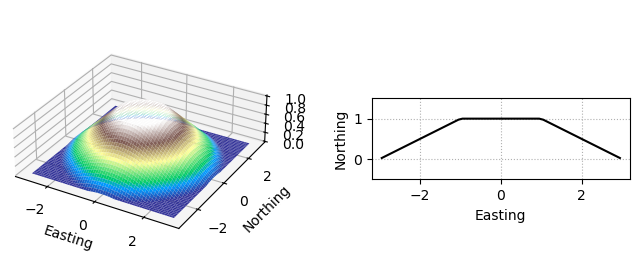

In [3]:
### Create subsurface grid: xgrd, ygrd, zgrd ###
# incx, incy, incz: grid spacing in x, y, z directions
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)
X, Y = np.meshgrid(x, y)

# Mountain-shaped topography
T = np.zeros(X.shape)
for iy in range(len(y)):
    for ix in range(len(x)):
        r = np.sqrt(X[iy, ix]**2 + Y[iy, ix]**2)
        if r <= 1:
            T[iy, ix] = 1.
        elif (1 <= r) and (r <= 3):
            T[iy, ix] = - 0.5*r + 1.5

### Create subsurface grid: xgrd, ygrd, zgrd ###
# Number of subsurface layers = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# For visualization
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # Store coordinates of the 8 vertices of each voxel
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# Convert to arrays
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

# dim: block size
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# Near Tokyo
# Declination (degree)
dec = -7.
# Inclination (degree)
inc = 50.

# Visualization
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 29
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### Input models

In [4]:
### Magnetization structure  ###

# Rotational ellipsoidal demagnetized body  
zcenter = -0.2
a_rad = 0.5  # radius
b_rad = 0.5
c_rad = 0.5

# ------------------------------------------------------------ #

# Time1
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -4

# Time2
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -2

# Time3
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = 1

# Time4
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = 5

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

### Estimated models

#### Parallel Inversion

In [5]:
# Read
with open('models/Params_case_1_2_parallel.pickle', 'rb') as f:
    params_par = pickle.load(f)
with open('models/Betas1_case_1_2_parallel.pickle', 'rb') as f:
    betas1_par = pickle.load(f)
with open('models/Betas2_case_1_2_parallel.pickle', 'rb') as f:
    betas2_par = pickle.load(f)
with open('models/Betas3_case_1_2_parallel.pickle', 'rb') as f:
    betas3_par = pickle.load(f)
with open('models/Betas4_case_1_2_parallel.pickle', 'rb') as f:
    betas4_par = pickle.load(f)

# optimal parameters  # estimated by L-curve  # For more details, refer to the executable file
num_opt_1_par, num_opt_2_par, num_opt_3_par, num_opt_4_par = 5, 6, 6, 6
print("optimal λ = {:.2f}, {:.2f}, {:.2f}, {:.2f}".format(params_par[num_opt_1_par], 
                                                                   params_par[num_opt_2_par], 
                                                                   params_par[num_opt_3_par], 
                                                                   params_par[num_opt_4_par])
     )

# optimal models
beta1_par_temp = betas1_par[num_opt_1_par]
beta2_par_temp = betas2_par[num_opt_2_par]
beta3_par_temp = betas3_par[num_opt_3_par]
beta4_par_temp = betas4_par[num_opt_4_par]

optimal λ = 17.78, 31.62, 31.62, 31.62


#### Differential Inversion

In [6]:
# Read
with open('models/Params_case_1_2_differential.pickle', 'rb') as f:
    params_dif = pickle.load(f)
with open('models/Betas_del12_case_1_2_differential.pickle', 'rb') as f:
    betas_del12_dif = pickle.load(f)
    
# optimal parameter  # estimated by L-curve  # For more details, refer to the executable file
num_opt_1_dif = 7
print("optimal λ = {:.2f}".format(params_dif[num_opt_1_dif]))

# optimal model
beta_del12_dif_temp = betas_del12_dif[num_opt_1_dif]
beta2_dif_temp = beta1_par_temp + beta_del12_dif_temp

optimal λ = 56.23


#### SC-TLI

In [7]:
# Read
with open('models/Params_case_1_2_new_4d-3.pickle', 'rb') as f:
    params_4d = pickle.load(f)
with open('models/Betas1_case_1_2_new_4d-3.pickle', 'rb') as f:
    betas1_4d = pickle.load(f)
with open('models/Betas2_case_1_2_new_4d-3.pickle', 'rb') as f:
    betas2_4d = pickle.load(f)
with open('models/Betas3_case_1_2_new_4d-3.pickle', 'rb') as f:
    betas3_4d = pickle.load(f)
with open('models/Betas4_case_1_2_new_4d-3.pickle', 'rb') as f:
    betas4_4d = pickle.load(f)

# optimal parameter  # estimated by L-curve  # For more details, refer to the executable file
num_opt_4d = 6
print("Optimal λs = {:2f}, λt = {}".format(params_4d[num_opt_4d][0], params_4d[num_opt_4d][1]))

# optimal models
beta1_4d_temp = betas1_4d[num_opt_4d]
beta2_4d_temp = betas2_4d[num_opt_4d]
beta3_4d_temp = betas3_4d[num_opt_4d]
beta4_4d_temp = betas4_4d[num_opt_4d]

Optimal λs = 31.622777, λt = 10.0


#### RMSE for temporal changes

In [8]:
# Table 3
columns = pd.MultiIndex.from_tuples([
    ("", "Par."), ("T2 - T1", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T3 - T2", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T4 - T3", "Diff."), ("", "SC-TLI"),
])

data_var = [["{:.4f}".format(calc_rmse(beta2 - beta1, beta2_par_temp - beta1_par_temp)), 
             "{:.4f}".format(calc_rmse(beta2 - beta1, beta2_dif_temp - beta1_par_temp)), 
             "{:.4f}".format(calc_rmse(beta2 - beta1, beta2_4d_temp  - beta1_4d_temp)), 
             "{:.4f}".format(calc_rmse(beta3 - beta2, beta3_par_temp - beta2_par_temp)), 
             "None", 
             "{:.4f}".format(calc_rmse(beta3 - beta2, beta3_4d_temp  - beta2_4d_temp)), 
             "{:.4f}".format(calc_rmse(beta4 - beta3, beta4_par_temp - beta3_par_temp)), 
             "None", 
             "{:.4f}".format(calc_rmse(beta4 - beta3, beta4_4d_temp -  beta3_4d_temp))],
]
index = ["Case 1-2"]

df_var = pd.DataFrame(data_var, index=index, columns=columns)
df_var

T2 - T1                 T3 - T2                 T4 - T3  \
            Par.   Diff.  SC-TLI    Par.   Diff.  SC-TLI    Par.   Diff.   
Case 1-2  0.0747  0.1167  0.0668  0.1465    None  0.1036  0.1166    None   

                  
          SC-TLI  
Case 1-2  0.1304

#### RMSE for each model

In [9]:
# Table 4
columns = pd.MultiIndex.from_tuples([
    ("", "Par."), ("T1", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T2", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T3", "Diff."), ("", "SC-TLI"),
    ("", "Par."), ("T4", "Diff."), ("", "SC-TLI"),
])

data = [["{:.3f}".format(calc_rmse(beta1, beta1_par_temp)), 
         "{:.3f}".format(calc_rmse(beta1, beta1_par_temp)), 
         "{:.3f}".format(calc_rmse(beta1, beta1_4d_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_par_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_dif_temp)), 
         "{:.3f}".format(calc_rmse(beta2, beta2_4d_temp)), 
         "{:.3f}".format(calc_rmse(beta3, beta3_par_temp)), 
         "None", 
         "{:.3f}".format(calc_rmse(beta3, beta3_4d_temp)),
         "{:.3f}".format(calc_rmse(beta4, beta4_par_temp)), 
         "None", 
         "{:.3f}".format(calc_rmse(beta4, beta4_4d_temp))],
]
index = ["Case 1-2"]

df = pd.DataFrame(data, index=index, columns=columns)
df

T1                   T2                  T3                \
           Par.  Diff. SC-TLI   Par.  Diff. SC-TLI   Par. Diff. SC-TLI   Par.   
Case 1-2  0.129  0.129  0.134  0.087  0.094  0.068  0.064  None  0.039  0.152   

            T4         
         Diff. SC-TLI  
Case 1-2  None  0.166

### Figure 11

In [ ]:
# Colormap
cmap = cm.get_cmap("RdBu")
norm = Normalize(vmin = -6, vmax = 6)

# Figure setup
fig = plt.figure(figsize = (14, 10))
plt.subplots_adjust(wspace=0.1, hspace=-0.45)

#--- Input models ---#

# T2 - T1
ax = fig.add_subplot(441)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta2 - beta1)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_2 - T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Input models", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(442)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta3 - beta2)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_3 - T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(443)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta4 - beta3)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T_4 - T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Parallel inversion ---#

# T2 - T1
ax = fig.add_subplot(445)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta2_par_temp - beta1_par_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Parallel inv.", fontsize=14,
#rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(446)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta3_par_temp - beta2_par_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(447)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta4_par_temp - beta3_par_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Differential inversion ---#

# T2 - T1
ax = fig.add_subplot(449)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta_del12_dif_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Differential inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T3 - T2
ax = fig.add_subplot(4,4,10)
       
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T4 - T3
ax = fig.add_subplot(4,4,11)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- 4D inversion ---#

# T2 - T1
ax = fig.add_subplot(4,4,13)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta2_4d_temp - beta1_4d_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "4D inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([])
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

# T3 - T2
ax = fig.add_subplot(4,4,14)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta3_4d_temp - beta2_4d_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

# T4 - T3
ax = fig.add_subplot(4,4,15)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = (beta4_4d_temp - beta3_4d_temp)[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%",  # 横幅（親軸に対する割合）
                 height="10%",  # 高さ（親軸に対する割合）
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), # 左端、下端
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal", cmap = "bwr_r")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization change (A/m)", fontsize = 12)

plt.savefig("Figure11.svg", dpi = 600, transparent = True)

C:\Users\ri710\AppData\Local\Temp\ipykernel_20440\1845826528.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu")


### Figure 15

In [ ]:
# Colormap
from matplotlib import cm
cmap = cm.get_cmap("RdYlBu")
norm = Normalize(vmin = -6, vmax = 6)

# Figure setup
fig = plt.figure(figsize = (14, 10))
plt.subplots_adjust(wspace=0.1, hspace=-0.45)

#--- Input models ---#

# T = T1
ax = fig.add_subplot(441)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Input models", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T = T2
ax = fig.add_subplot(442)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(443)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(444)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$", fontsize = 14)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Parallel inversion ---#

# T = T1
ax = fig.add_subplot(445)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1_par_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Parallel inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T = T2
ax = fig.add_subplot(446)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2_par_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(447)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3_par_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(448)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4_par_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- Differential inversion ---#

# T = T1
ax = fig.add_subplot(449)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1_par_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelbottom=False)
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "Differential inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

# T = T2
ax = fig.add_subplot(4,4,10)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2_dif_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T3
ax = fig.add_subplot(4,4,11)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)

# T = T4
ax = fig.add_subplot(4,4,12)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
#ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False, labelbottom=False)
ax.tick_params(width = 1, length = 1)


#--- 4D inversion ---#

# T = T1
ax = fig.add_subplot(4,4,13)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta1_4d_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_1$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(width = 1, length = 1)

#ax.text(-0.35, 0.5, "4D inv.", fontsize=14,
#        rotation=90, va='center', ha='center',
#        transform=ax.transAxes)

#--- colorbar ---#
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
p = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
p.set_array([]) 
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1), 
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T2
ax = fig.add_subplot(4,4,14)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta2_4d_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_2$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T3
ax = fig.add_subplot(4,4,15)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta3_4d_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_3$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%", 
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

# T = T4
ax = fig.add_subplot(4,4,16)

# Cross-section
for i in range(len(xgrd)):
    
    # Coordinates
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # Slice condition
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # Cell dimensions
        width  = x_max - x_min
        height = z_max - z_min

        beta_val = beta4_4d_temp[i]
        color = cmap(norm(beta_val))

        # Draw rectangle
        rect = Rectangle((x_min, z_min), width, height,
                         facecolor=color, edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)
        
ax.set_xticks([-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0])
ax.set_yticks([-1.0, 0.0, 1.0])
ax.set_aspect("equal")
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-1.7, 1.5)
ax.set_xlabel("Easting (km)")
#ax.set_ylabel("Altitude (km)")
#ax.set_title("$T = T_4$")
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.tick_params(labelleft=False)
ax.tick_params(width = 1, length = 1)

#--- colorbar ---#
cax = inset_axes(ax,
                 width="85%",
                 height="10%",
                 loc='lower center',
                 bbox_to_anchor=(0, -0.7, 1, 1),
                 bbox_transform=ax.transAxes,
                 borderpad=0)
cbar = fig.colorbar(p, cax=cax, orientation="horizontal")
#cbar.set_label("Magnetization Intensity (A/m)", rotation=0, labelpad=10, size=12)
cbar.ax.set_title("Magnetization (A/m)", fontsize = 12)

plt.savefig("Figure15.svg", dpi = 600, transparent = True)